# Классификация тональности твитов

Задача проекта: определить эмоциональную окраску твита о коронавирусе по его тексту.

В проекте сравниваются Bag of Words и TF-IDF, реализуется собственный tokenizer для Twitter-текстов, проверяется stemming и влияние фильтрации редких токенов.

## Импорты и данные

In [ ]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [ ]:
df = pd.read_csv('tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
12508,18965,63917,"San Francisco, Bay Area, CA",22-03-2020,"CoronaVirus Antidotes- Home Test, Toilet Paper...",Extremely Positive
24975,34378,79330,"Brussels, Belgium and Plovdiv, Bulgaria",06-04-2020,Responses of consumption and prices in Japan t...,Extremely Negative
23522,32533,77485,"???????????, ?????",05-04-2020,On a lighter note For all spaghetti western mo...,Positive
24236,33436,78388,Bahrain,05-04-2020,"Saudi-based office lunch delivery platform, @D...",Extremely Positive


## Подготовка целевой переменной и train/test split

In [ ]:
df['Sentiment']=df['Sentiment'].replace({'Positive':1,'Extremely Positive':1,'Negative':0,'Extremely Negative':0})
df

/tmp/ipykernel_31122/3070580660.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sentiment']=df['Sentiment'].replace({'Positive':1,'Extremely Positive':1,'Negative':0,'Extremely Negative':0})


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,1
1,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,1
2,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,1
3,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",0
4,3804,48756,"ÃÂT: 36.319708,-82.363649",16-03-2020,As news of the regionÃÂs first confirmed COV...,1
...,...,...,...,...,...,...
33439,44949,89901,OHIO,14-04-2020,I never that weÃÂd be in a situation &amp; w...,1
33440,44950,89902,NaN,14-04-2020,@MrSilverScott you are definitely my man. I fe...,1
33441,44952,89904,NaN,14-04-2020,Response to complaint not provided citing COVI...,0
33442,44953,89905,NaN,14-04-2020,You know itÃÂs getting tough when @KameronWi...,1


In [ ]:
df['Sentiment'].value_counts(normalize=True)

,proportion
Sentiment,
1,0.539589
0,0.460411


Классы близки по размеру: около 54% положительных и 46% отрицательных твитов, поэтому сильного дисбаланса нет.

In [ ]:
df.isna().sum()

,0
UserName,0
ScreenName,0
Location,7049
TweetAt,0
OriginalTweet,0
Sentiment,0


In [ ]:
df = df.fillna('Unknown')

In [ ]:
from sklearn.model_selection import train_test_split

train, test =train_test_split(df,test_size=0.3,random_state=0)

## Анализ токенов

In [ ]:
voc_for_tokens = {}
for tweet in train['OriginalTweet']:
  tokens=tweet.lower().split()
  for symb in tokens:
    if symb not in voc_for_tokens:
      voc_for_tokens[symb]=1
    else:
      voc_for_tokens[symb]+=1

voc_for_tokens

{'why': 654,
 'we': 3787,
 'still': 763,
 'want': 487,
 'to': 23373,
 'buy': 748,
 'so': 1837,
 'much': 482,
 'stuff': 106,
 'during': 1908,
 'quarantine': 154,
 'https://t.co/1m881cwfuv': 1,
 '#shopping': 121,
 '#covid_19': 1660,
 '#online': 40,
 'with': 4063,
 'driving': 77,
 'even': 682,
 'more': 2008,
 'usage': 22,
 'a': 11737,
 'strong': 93,
 'strategy': 33,
 'is': 7383,
 'critical': 156,
 'now': 1349,
 'then': 435,
 'ever': 179,
 'luckily': 8,
 'and': 14684,
 'april': 163,
 '16': 36,
 'webinar': 65,
 'will': 2726,
 'dive': 10,
 'into': 666,
 'growing': 84,
 'app': 52,
 'awareness': 32,
 'targeting': 9,
 'high': 408,
 'lifetime': 4,
 'value': 79,
 'users': 19,
 '@canon_india': 16,
 'i': 5340,
 'am': 424,
 'very': 418,
 'happy..': 1,
 'great': 409,
 'job': 242,
 'by': 2236,
 '#canonforcommunity': 5,
 'https://t.co/z0intks34x': 1,
 'the': 26815,
 'u.s': 8,
 'national': 123,
 'debt': 68,
 'likely': 170,
 'exceed': 14,
 '$30': 7,
 'trillion': 21,
 'after': 886,
 'unprecedented': 89,
 

In [ ]:
popular=pd.Series(voc_for_tokens).sort_values(ascending=False).head(10)
popular

,0
the,26815
to,23373
and,14684
of,13012
a,11737
in,11198
for,8566
#coronavirus,8223
is,7383
are,7050


Простое разбиение по пробелам оставляет много стоп-слов и шумных токенов. Для Twitter-текстов дальше используется `TweetTokenizer`.

In [ ]:
import nltk
from nltk.corpus import stopwords

voc_without_stopwords={}
nltk.download("stopwords", quiet=True)
sw = stopwords.words('english')
for i,j in voc_for_tokens.items():
  if i not in sw:
    voc_without_stopwords[i] = j


voc_without_stopwords

{'still': 763,
 'want': 487,
 'buy': 748,
 'much': 482,
 'stuff': 106,
 'quarantine': 154,
 'https://t.co/1m881cwfuv': 1,
 '#shopping': 121,
 '#covid_19': 1660,
 '#online': 40,
 'driving': 77,
 'even': 682,
 'usage': 22,
 'strong': 93,
 'strategy': 33,
 'critical': 156,
 'ever': 179,
 'luckily': 8,
 'april': 163,
 '16': 36,
 'webinar': 65,
 'dive': 10,
 'growing': 84,
 'app': 52,
 'awareness': 32,
 'targeting': 9,
 'high': 408,
 'lifetime': 4,
 'value': 79,
 'users': 19,
 '@canon_india': 16,
 'happy..': 1,
 'great': 409,
 'job': 242,
 '#canonforcommunity': 5,
 'https://t.co/z0intks34x': 1,
 'u.s': 8,
 'national': 123,
 'debt': 68,
 'likely': 170,
 'exceed': 14,
 '$30': 7,
 'trillion': 21,
 'unprecedented': 89,
 'borrowing': 5,
 'trump': 228,
 'administration': 38,
 'mnuchinã\x82â\x92s': 1,
 'treasury': 3,
 '#coronavirus': 8223,
 'crisis.': 162,
 'federal': 99,
 'reserve': 17,
 'could': 640,
 'cushion': 9,
 'blow.': 4,
 'consumer': 2245,
 'led': 67,
 'economy': 244,
 'brink.': 1,
 'fina

In [ ]:
popular_without_stopwords=pd.Series(voc_without_stopwords).sort_values(ascending=False).head(10)
popular_without_stopwords

,0
#coronavirus,8223
prices,3891
food,3820
grocery,3469
supermarket,3288
people,3175
covid-19,3173
store,3155
#covid19,2471
&amp;,2314


In [ ]:
from nltk.tokenize import TweetTokenizer

tweet_voc={}
tw = TweetTokenizer()
for tweet in train['OriginalTweet']:
  tokens=tw.tokenize(tweet.lower())
  for symb in tokens:
    if symb not in tweet_voc:
      tweet_voc[symb]=1
    else:
      tweet_voc[symb]+=1
tweet_voc

{'why': 718,
 'we': 3879,
 'still': 788,
 'want': 500,
 'to': 23478,
 'buy': 808,
 'so': 1929,
 'much': 514,
 'stuff': 142,
 'during': 1913,
 'quarantine': 209,
 'https://t.co/1m881cwfuv': 1,
 '#shopping': 121,
 '#covid_19': 1734,
 '#online': 41,
 'with': 4114,
 'driving': 80,
 'even': 691,
 'more': 2223,
 'usage': 25,
 'a': 11891,
 'strong': 136,
 'strategy': 43,
 'is': 7464,
 'critical': 162,
 'now': 1827,
 'then': 463,
 'ever': 228,
 'luckily': 13,
 'and': 14825,
 'april': 188,
 '16': 48,
 'webinar': 71,
 'will': 2746,
 'dive': 11,
 'into': 672,
 'growing': 95,
 'app': 66,
 'awareness': 36,
 'targeting': 10,
 'high': 434,
 'lifetime': 6,
 'value': 93,
 'users': 21,
 '@canon_india': 16,
 'i': 5478,
 'am': 464,
 'very': 425,
 'happy': 108,
 '..': 404,
 'great': 431,
 'job': 281,
 'by': 2255,
 '#canonforcommunity': 5,
 'https://t.co/z0intks34x': 1,
 'the': 26993,
 'u': 409,
 '.': 24118,
 's': 3061,
 'national': 124,
 'debt': 89,
 'likely': 172,
 'exceed': 14,
 '$': 863,
 '30': 138,
 't

In [ ]:
popular_tweet=pd.Series(tweet_voc).sort_values(ascending=False).head(10)
popular_tweet

,0
the,26993
.,24118
to,23478
",",17571
and,14825
of,13044
a,11891
in,11348
?,9524
#coronavirus,8808


In [ ]:
from string import punctuation

tweet_voc_without_noise={}
nltk.download("stopwords", quiet=True)
sw = stopwords.words('english')
noise = sw + list(punctuation)
for i,j in tweet_voc.items():
  if i not in noise:
    tweet_voc_without_noise[i]=j


In [ ]:
popular_without_noise=pd.Series(tweet_voc_without_noise).sort_values(ascending=False).head(10)
popular_without_noise

,0
#coronavirus,8808
â,7415
,7311
19,7167
covid,6253
prices,4601
,4372
food,4367
store,3877
supermarket,3805


In [ ]:
tweet_voc_clean = {}
for i, j in tweet_voc_without_noise.items():
  if not (len(i) == 1 and ord(i) >= 128):
    tweet_voc_clean[i] = j

In [ ]:
popular_without_noise=pd.Series(tweet_voc_clean).sort_values(ascending=False).head(10)
popular_without_noise

,0
#coronavirus,8808
19,7167
covid,6253
prices,4601
food,4367
store,3877
supermarket,3805
grocery,3523
people,3463
#covid19,2589


## Собственный tokenizer

In [ ]:
def custom_tokenizer(text):
  custom_tokens=[]
  tw=TweetTokenizer()
  nltk.download("stopwords", quiet=True)
  sw = stopwords.words('english')
  noise = sw + list(punctuation)
  tokens=tw.tokenize(text.lower())
  for i in tokens:
    if i not in noise:
      if not (len(i)==1 and ord(i)>=128):
        if not i.startswith('https://t.co'):
          custom_tokens.append(i)
  tokens=custom_tokens
  return tokens


In [ ]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

Tokenizer приводит текст к нижнему регистру, использует `TweetTokenizer`, удаляет английские stop words, пунктуацию, единичные мусорные символы и ссылки вида `https://t.co`.

## CountVectorizer и TF-IDF

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer)
X_train_cv=cv.fit_transform(train['OriginalTweet'])
X_test_cv=cv.transform(test['OriginalTweet'])
print(len(cv.vocabulary_))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


45290


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer(tokenizer=custom_tokenizer)
X_train_tfidf=tfidf_vec.fit_transform(train['OriginalTweet'])
X_test_tfidf=tfidf_vec.transform(test['OriginalTweet'])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


После очистки словарь CountVectorizer содержит 45 290 токенов.

## Logistic Regression: CountVectorizer vs TF-IDF

In [ ]:
cv = CountVectorizer(tokenizer=custom_tokenizer)
X_train_cv=cv.fit_transform(train['OriginalTweet'])
X_test_cv=cv.transform(test['OriginalTweet'])

tfidf_vec = TfidfVectorizer(tokenizer=custom_tokenizer)
X_train_tfidf=tfidf_vec.fit_transform(train['OriginalTweet'])
X_test_tfidf=tfidf_vec.transform(test['OriginalTweet'])
y_train=train['Sentiment']
y_test=test['Sentiment']

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf_cv = LogisticRegression(max_iter=200, random_state=42)
clf_cv.fit(X_train_cv, y_train)
pred_train_cv=clf_cv.predict(X_train_cv)
pred_test_cv=clf_cv.predict(X_test_cv)
print(accuracy_score(y_train,pred_train_cv))
print(accuracy_score(y_test,pred_test_cv))

0.9846646732165741
0.8670520231213873


In [ ]:
clf_tfidf = LogisticRegression(max_iter=300, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)
pred_train_tfidf=clf_tfidf.predict(X_train_tfidf)
pred_test_tfidf=clf_tfidf.predict(X_test_tfidf)
print(accuracy_score(y_train,pred_train_tfidf))
print(accuracy_score(y_test,pred_test_tfidf))

0.9224263135412217
0.85280047837353


CountVectorizer показал лучший test accuracy: около `0.867`, против `0.853` у TF-IDF.

На train у CountVectorizer качество заметно выше, поэтому у модели есть признаки переобучения.

## Stemming

In [ ]:
from nltk.stem.snowball import SnowballStemmer

def custom_stem_tokenizer(text):
  stemmer = SnowballStemmer("english")
  stemmed=custom_tokenizer(text)
  tokens = [stemmer.stem(w) for w in stemmed]

  return tokens

In [ ]:
cv = CountVectorizer(tokenizer=custom_stem_tokenizer).fit(train['OriginalTweet'])

print(len(cv.vocabulary_))

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36634


In [ ]:
X_train_cv=cv.transform(train['OriginalTweet'])
X_test_cv=cv.transform(test['OriginalTweet'])
tfidf_vec = TfidfVectorizer(tokenizer=custom_stem_tokenizer)
X_train_tfidf=tfidf_vec.fit_transform(train['OriginalTweet'])
X_test_tfidf=tfidf_vec.transform(test['OriginalTweet'])

clf_cv = LogisticRegression(max_iter=200, random_state=42)
clf_cv .fit(X_train_cv, y_train)
pred_train_cv=clf_cv.predict(X_train_cv)
pred_test_cv=clf_cv.predict(X_test_cv)
print(accuracy_score(y_train, pred_train_cv))
print(accuracy_score(y_test, pred_test_cv))




0.9720205040580948
0.8674506677297189


In [ ]:
clf_tfidf = LogisticRegression(max_iter=300, random_state=42)
clf_tfidf.fit(X_train_tfidf, y_train)
pred_train_tfidf=clf_tfidf.predict(X_train_tfidf)
pred_test_tfidf=clf_tfidf.predict(X_test_tfidf)

print(accuracy_score(y_train, pred_train_tfidf))
print(accuracy_score(y_test, pred_test_tfidf))

0.9165741136266553
0.8559896352401833


Stemming уменьшил размер словаря с 45 290 до 36 634 токенов.

Для CountVectorizer test accuracy практически не изменился: около `0.8675`. Для TF-IDF test accuracy составил около `0.856`.

## Фильтрация редких токенов

In [ ]:
cv_df = CountVectorizer(tokenizer=custom_stem_tokenizer,
                        min_df=11
                        ).fit(
                             train['OriginalTweet']
                            )
print(len(cv_df.vocabulary_))

3687


In [ ]:
X_train_cv=cv_df.transform(train['OriginalTweet'])
X_test_cv=cv_df.transform(test['OriginalTweet'])
clf_df = LogisticRegression(max_iter=200, random_state=42)
clf_df.fit(X_train_cv, y_train)
pred_train=clf_df.predict(X_train_cv)
pred_test=clf_df.predict(X_test_cv)
print(accuracy_score(y_train,pred_train))
print(accuracy_score(y_test,pred_test))

0.9290046988466467
0.8680486346422165


При `min_df=11` словарь сократился до 3 687 признаков, а test accuracy немного вырос до `0.8680`.

Это лучший test accuracy среди проверенных в notebook вариантов.

## Проверка масштабирования

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler(with_mean=False)
X_train=scaler.fit_transform(X_train_cv)
X_test=scaler.transform(X_test_cv)
clf_scaled = LogisticRegression(max_iter=200, random_state=42)
clf_scaled.fit(X_train, y_train)
pred_train=clf_scaled.predict(X_train)
pred_test=clf_scaled.predict(X_test)
print(accuracy_score(y_train,pred_train))
print(accuracy_score(y_test,pred_test))

0.9414780008543358
0.8447279250548136


Масштабирование sparse-признаков через `StandardScaler(with_mean=False)` ухудшило test accuracy до `0.8447`, поэтому в этой задаче оно не помогло.

## Дополнительный анализ даты

<Axes: xlabel='TweetAt', ylabel='Count'>

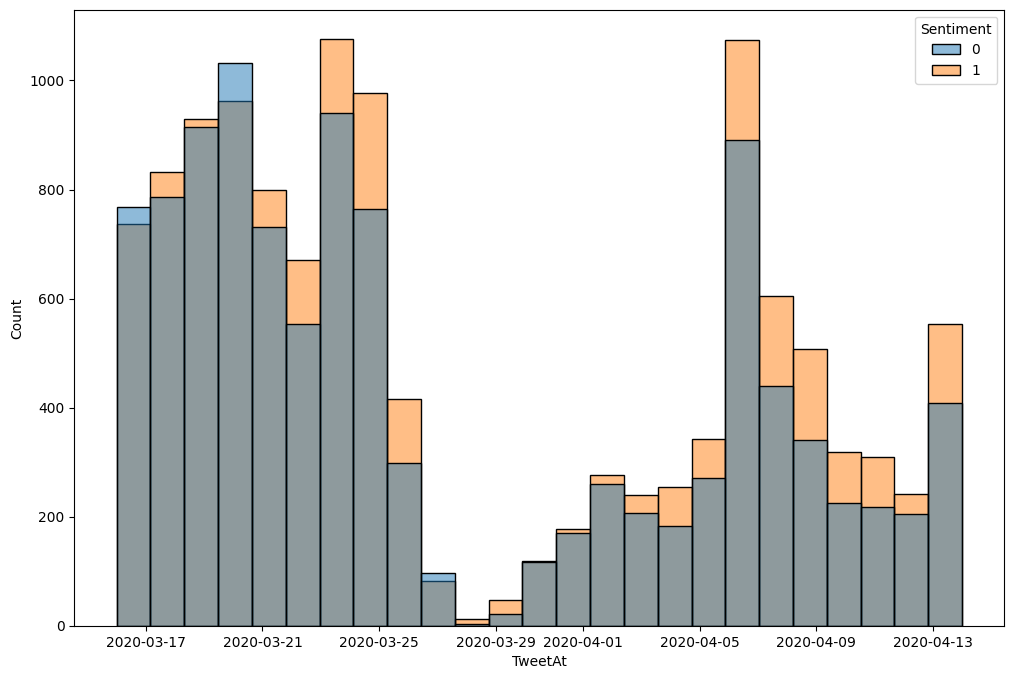

In [ ]:
train_for_hist=train.copy()
train_for_hist['TweetAt']=pd.to_datetime(train_for_hist['TweetAt'],dayfirst=True)
plt.figure(figsize=(12,8))
sns.histplot(data=train_for_hist,x='TweetAt',hue='Sentiment')

Распределения положительных и отрицательных твитов по датам сильно перекрываются, поэтому `TweetAt` не выглядит полезным признаком для классификации.